# Graduate Employability Prediction Using Machine Learning

## Step 1: Import Required Libraries

In [1]:
# ============================================
# Import Required Libraries
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("ggplot")

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# Load Dataset

df = pd.read_csv("../data/raw/student_placement_synthetic.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status
0,EE,Tier-2,6.75,0,4.9,5.7,60.7,4.2,5.8,3.1,3,0,2,1,0,0,1
1,IT,Tier-2,9.93,0,2.4,5.8,77.6,2.1,4.3,9.0,1,4,2,2,1,1,0
2,CE,Tier-3,5.54,2,2.9,6.7,91.3,2.3,1.9,7.8,1,3,0,1,0,0,0
3,Chemical,Tier-1,5.37,0,4.4,5.8,74.9,3.8,4.5,7.2,2,1,1,2,0,0,0
4,EE,Tier-2,9.77,0,3.9,3.8,35.6,9.4,6.5,4.8,1,2,0,0,1,1,1


## Step 3: Dataset Shape

In [4]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 305000
Number of Columns : 17


## Step 4: Dataset Information

In [5]:
# ============================================
# Dataset Information
# ============================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 305000 entries, 0 to 304999
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     302015 non-null  str    
 1   college_tier               305000 non-null  str    
 2   cgpa                       298954 non-null  float64
 3   backlogs                   305000 non-null  int64  
 4   coding_skills              300376 non-null  float64
 5   dsa_score                  305000 non-null  float64
 6   aptitude_score             305000 non-null  float64
 7   communication_skills       305000 non-null  float64
 8   ml_knowledge               305000 non-null  float64
 9   system_design              305000 non-null  float64
 10  internships                305000 non-null  int64  
 11  projects_count             305000 non-null  int64  
 12  certifications             305000 non-null  int64  
 13  hackathons                 305000 non-nu

## Step 5: Statistical Summary

In [6]:
# ============================================
# Statistical Summary
# ============================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
cgpa,298954.0,7.496302,1.444449,5.0,6.24,7.5,8.75,10.0
backlogs,305000.0,0.291780,0.654661,0.0,0.00,0.0,0.00,3.0
coding_skills,300376.0,5.506465,2.598585,1.0,3.30,5.5,7.80,10.0
dsa_score,305000.0,5.501045,2.598305,1.0,3.30,5.5,7.70,10.0
aptitude_score,305000.0,65.000605,20.204345,30.0,47.50,65.0,82.50,100.0
communication_skills,305000.0,5.495264,2.596368,1.0,3.20,5.5,7.70,10.0
ml_knowledge,305000.0,5.500014,2.597515,1.0,3.30,5.5,7.70,10.0
system_design,305000.0,5.498115,2.600002,1.0,3.20,5.5,7.70,10.0
internships,305000.0,1.501059,1.118161,0.0,1.00,1.0,3.00,3.0
projects_count,305000.0,1.998577,1.412619,0.0,1.00,2.0,3.00,4.0


## Step 6: Check Missing Values

In [7]:
# ============================================
# Missing Values
# ============================================

missing_values = df.isnull().sum()

missing_values

branch                       2985
college_tier                    0
cgpa                         6046
backlogs                        0
coding_skills                4624
dsa_score                       0
aptitude_score                  0
communication_skills            0
ml_knowledge                    0
system_design                   0
internships                     0
projects_count                  0
certifications                  0
hackathons                      0
open_source_contributions       0
extracurriculars                0
placement_status                0
dtype: int64

In [8]:
missing_values[missing_values > 0]

branch           2985
cgpa             6046
coding_skills    4624
dtype: int64

## Step 7: Check Duplicate Records

In [9]:
# ============================================
# Duplicate Records
# ============================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 5000


In [10]:
## Step 8: Handling Missing Values

In [11]:
# ============================================
# Handling Missing Values
# ============================================

# Categorical Feature
df["branch"] = df["branch"].fillna(df["branch"].mode()[0])

# Numerical Features
df["cgpa"] = df["cgpa"].fillna(df["cgpa"].median())

df["coding_skills"] = df["coding_skills"].fillna(
    df["coding_skills"].median()
)

print("Missing values handled successfully.")

Missing values handled successfully.


In [12]:
df.isnull().sum()

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
dtype: int64

## Step 9: Duplicate Record Analysis

In [13]:
# ============================================
# Step 9: Duplicate Record Analysis
# ============================================

duplicate_records = df.duplicated().sum()

print(f"Number of Duplicate Records : {duplicate_records}")

Number of Duplicate Records : 5000


In [14]:
# Remove duplicate records

df.drop_duplicates(inplace=True)

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [15]:
print(f"Duplicate Records : {df.duplicated().sum()}")

Duplicate Records : 0


## Step 10: Target Variable Analysis

In [16]:
# ============================================
# Target Variable Distribution
# ============================================

df["placement_status"].value_counts()

placement_status
1    163349
0    136651
Name: count, dtype: int64

In [17]:
# Percentage Distribution

(df["placement_status"].value_counts(normalize=True) * 100).round(2)

placement_status
1    54.45
0    45.55
Name: proportion, dtype: float64

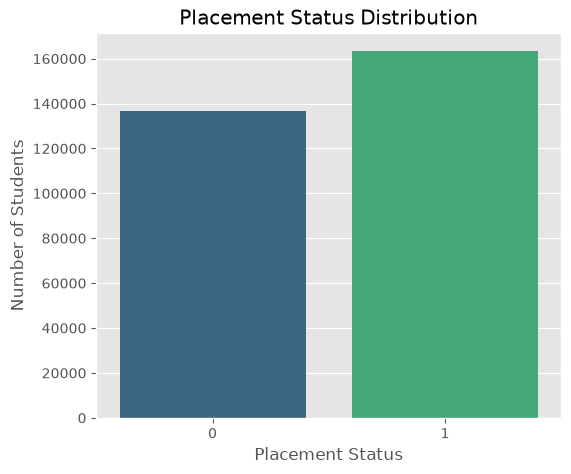

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="placement_status",
    data=df,
    palette="viridis"
)

plt.title("Placement Status Distribution")

plt.xlabel("Placement Status")

plt.ylabel("Number of Students")

plt.show()

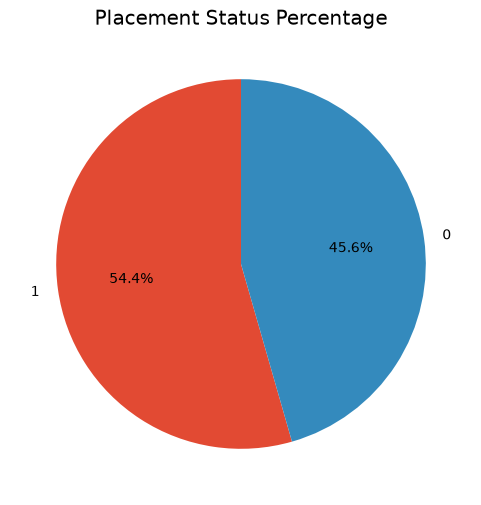

In [19]:
plt.figure(figsize=(6,6))

df["placement_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Placement Status Percentage")

plt.show()

## Step 11: Numerical Feature Analysis

In [20]:
# ============================================
# Numerical Features
# ============================================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Number of Numerical Features :", len(numerical_columns))
print(numerical_columns.tolist())

Number of Numerical Features : 15
['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars', 'placement_status']


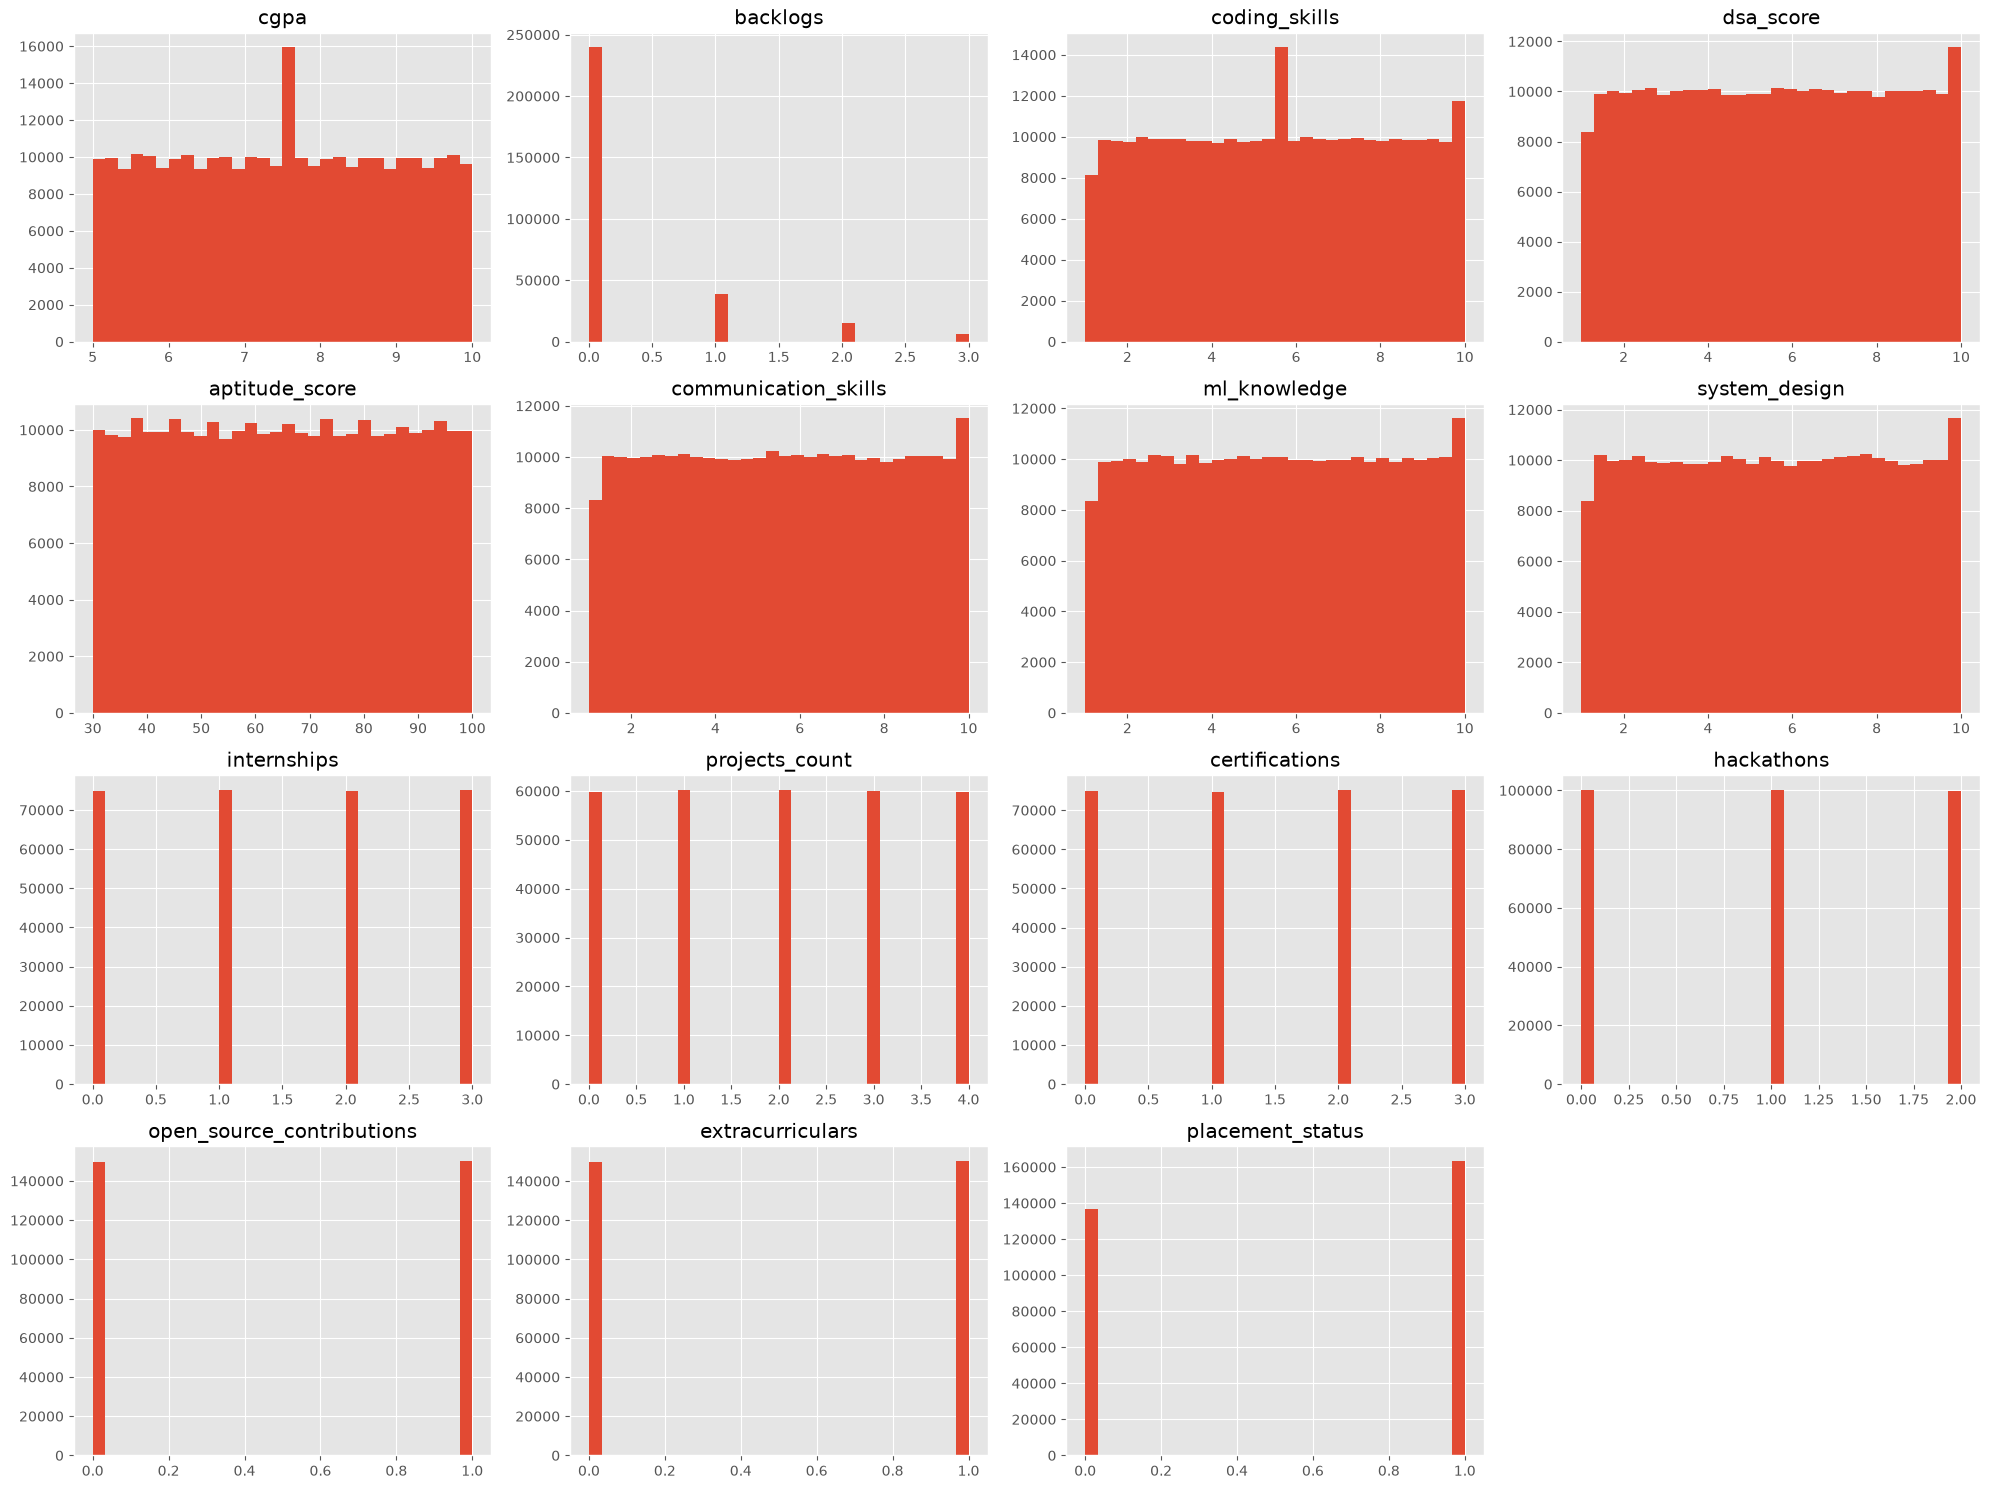

In [21]:
# ============================================
# Histograms
# ============================================

df[numerical_columns].hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()

plt.show()

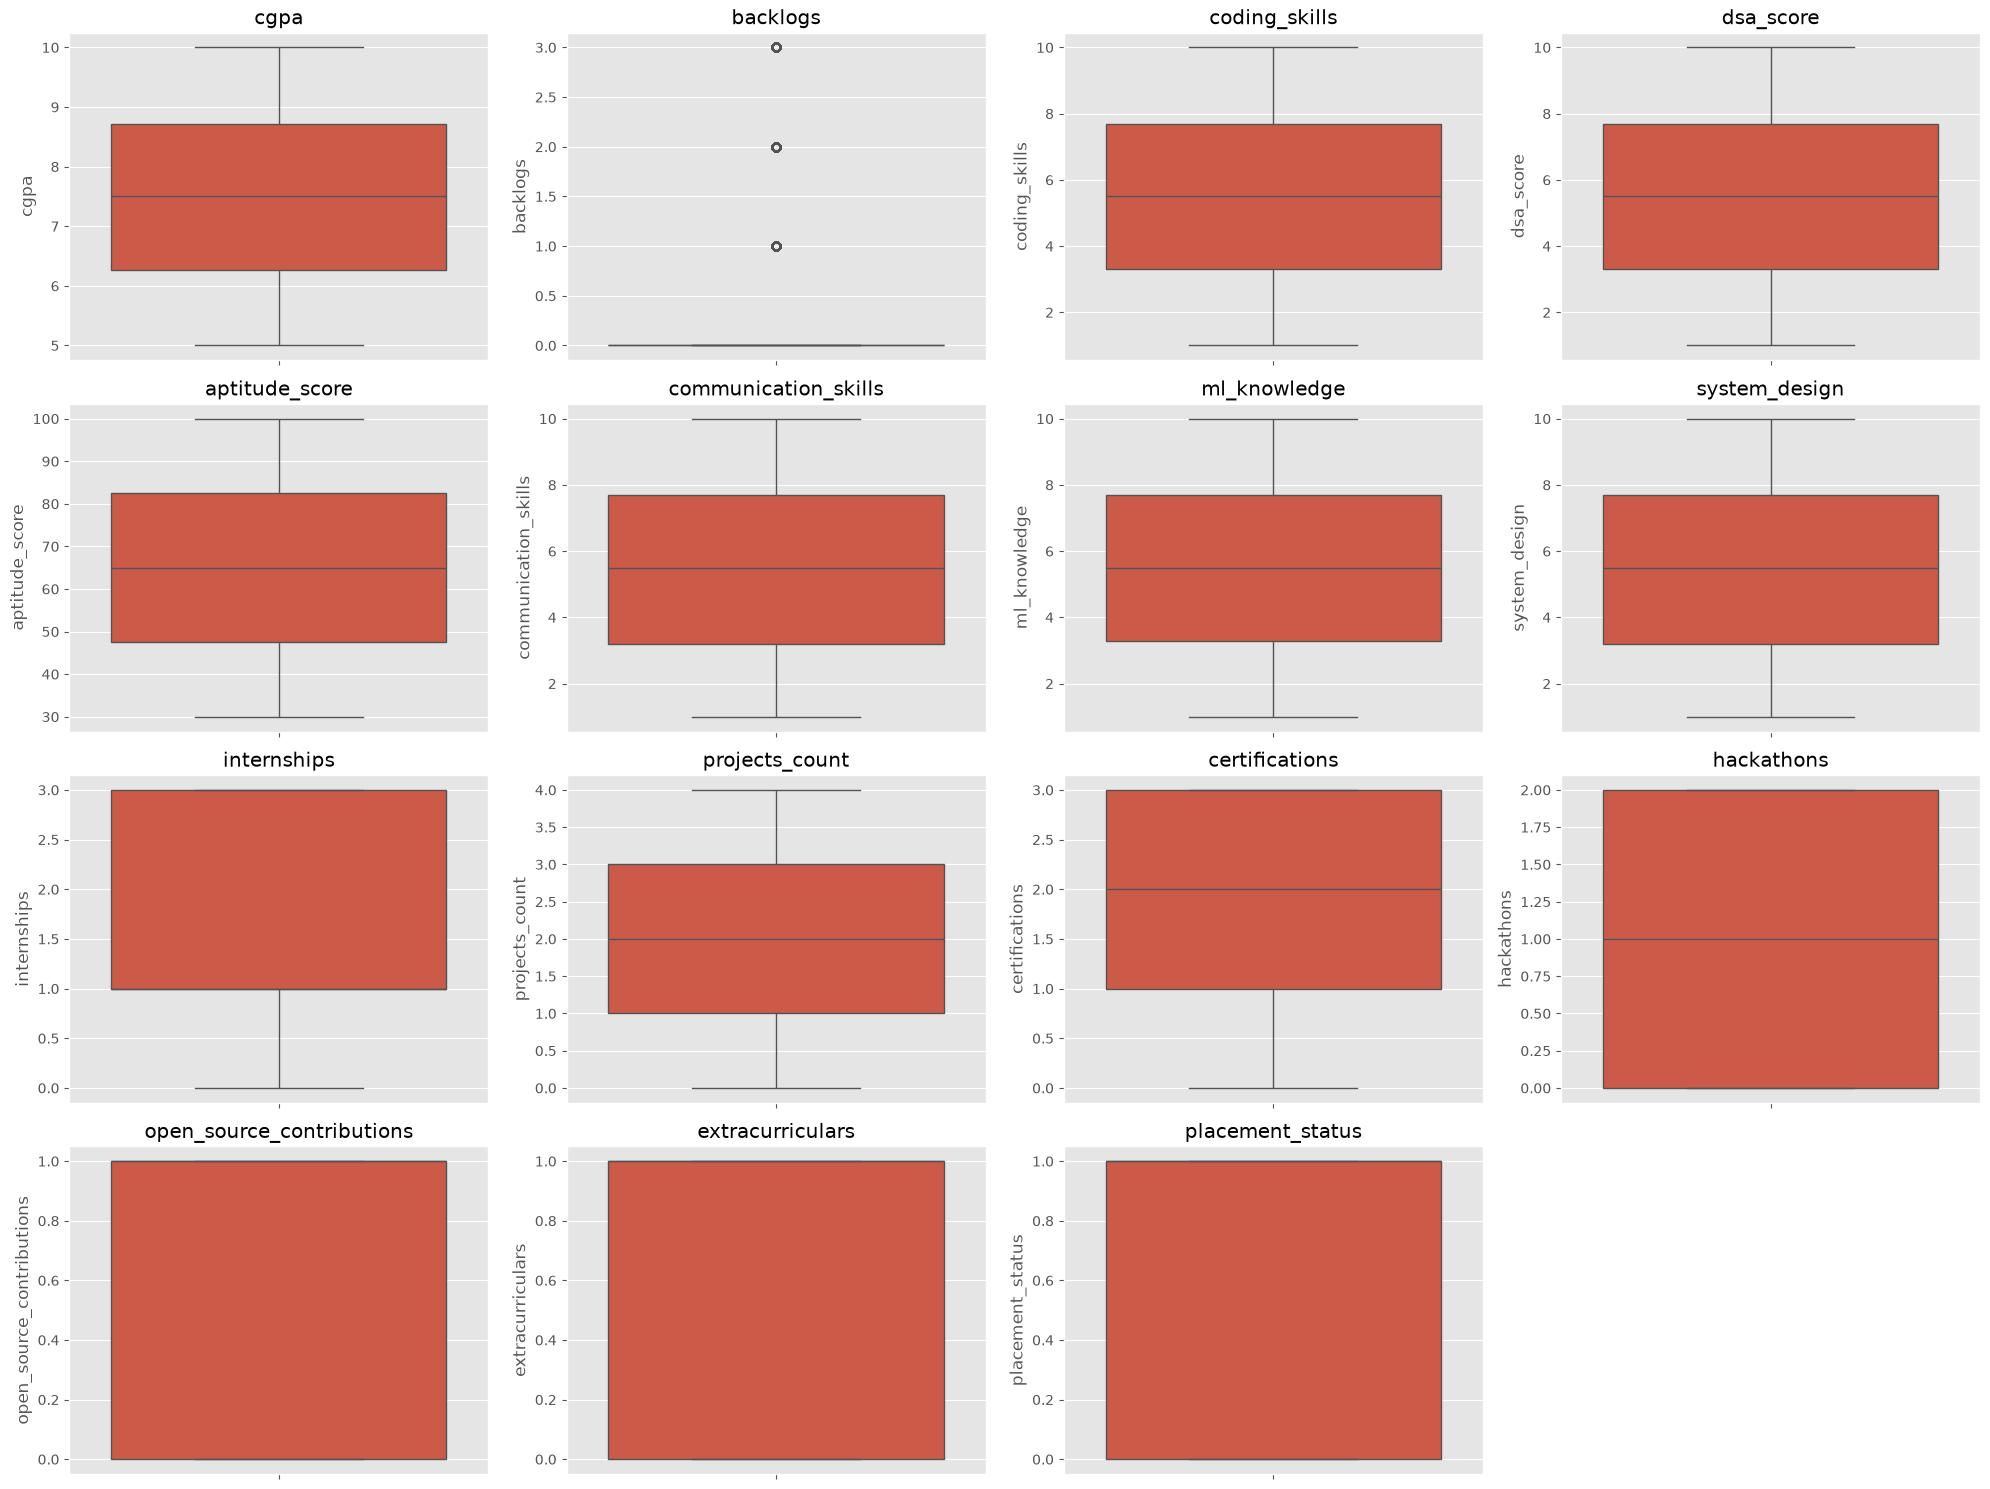

In [22]:
# ============================================
# Boxplots
# ============================================

plt.figure(figsize=(20,15))

for i, column in enumerate(numerical_columns, 1):

    plt.subplot(4,4,i)

    sns.boxplot(y=df[column])

    plt.title(column)

plt.tight_layout()

plt.show()

## Step 12: Categorical Feature Analysis

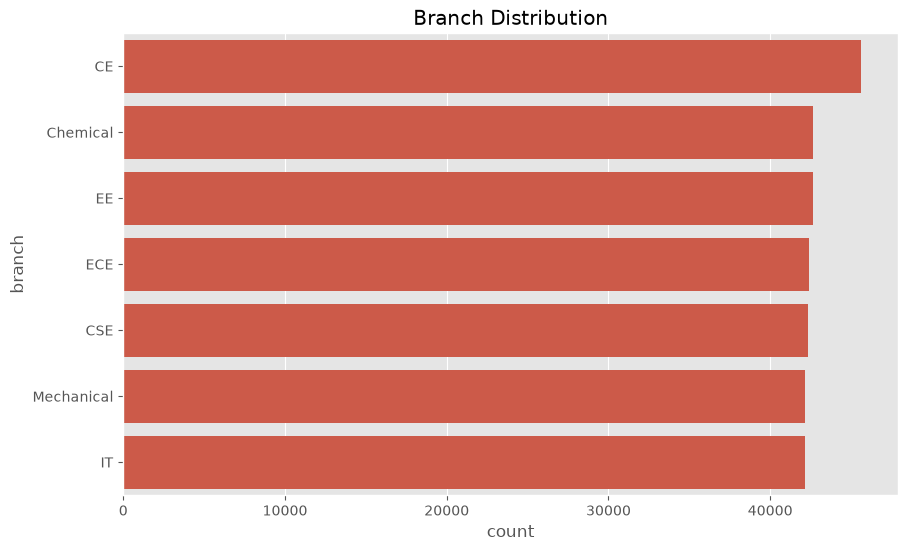

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="branch",
    data=df,
    order=df["branch"].value_counts().index
)

plt.title("Branch Distribution")

plt.show()

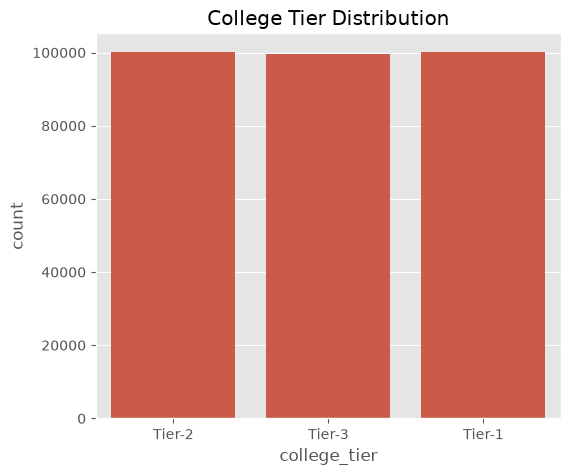

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="college_tier",
    data=df
)

plt.title("College Tier Distribution")

plt.show()

## Step 13:Correlation Analysis

In [25]:
temp_df = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

temp_df["branch"] = le.fit_transform(temp_df["branch"])
temp_df["college_tier"] = le.fit_transform(temp_df["college_tier"])

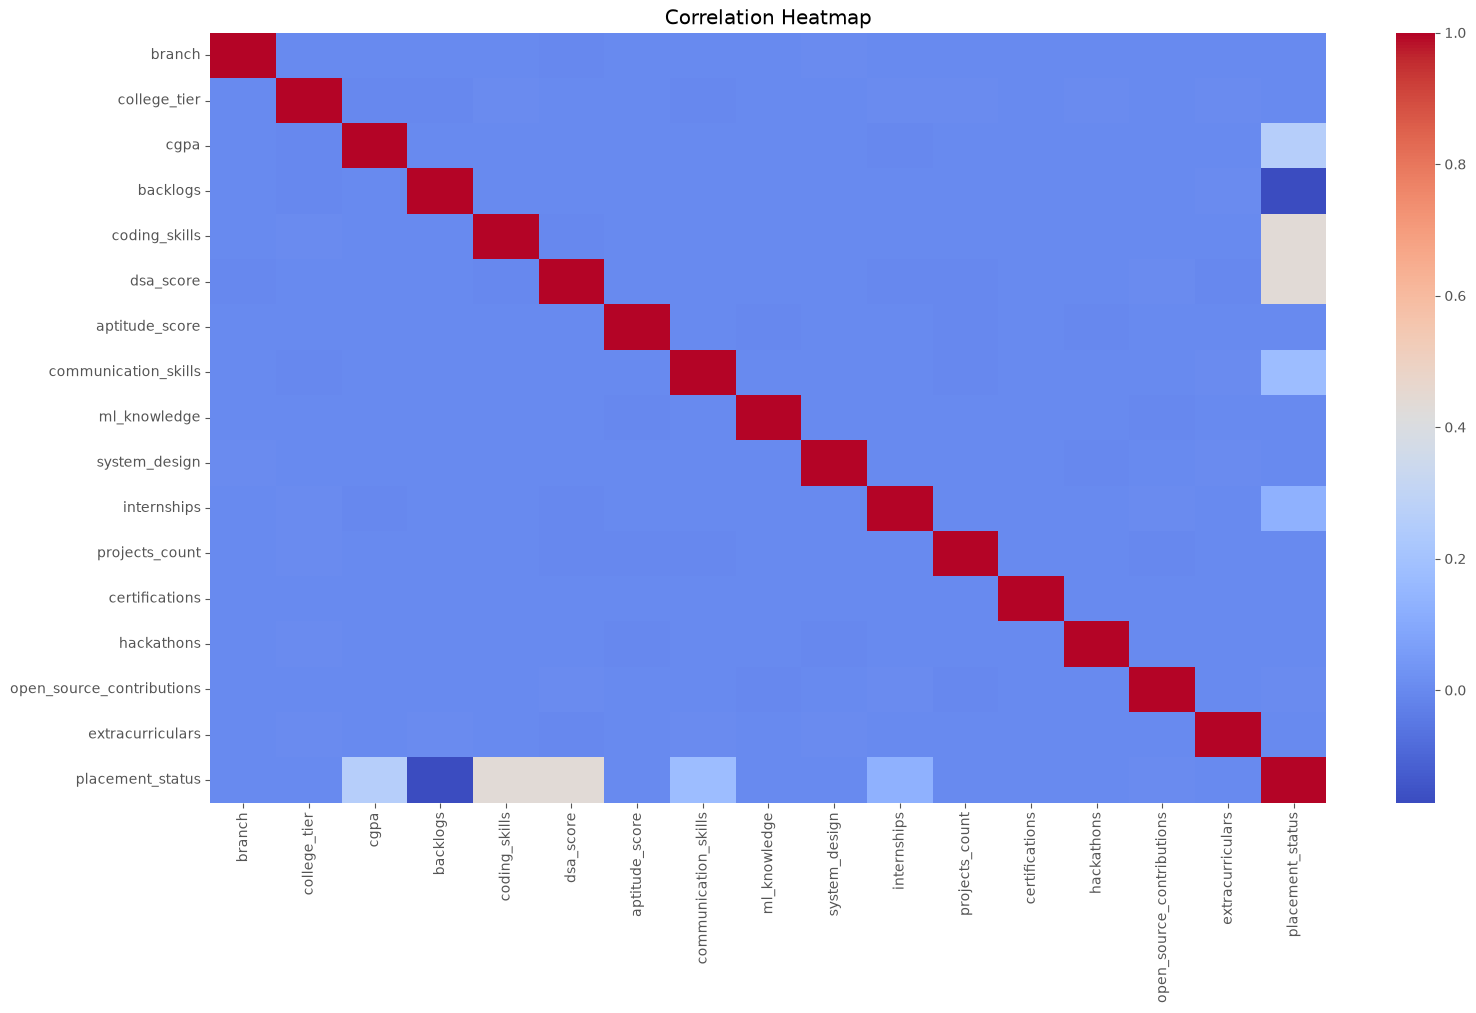

In [26]:
plt.figure(figsize=(18,10))

sns.heatmap(
    temp_df.corr(),
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Step 14: Advanced Feature Engineering

In [27]:
# ============================================
# Create a Copy of the Dataset
# ============================================

feature_df = df.copy()

print("Feature Engineering Started")

Feature Engineering Started


In [28]:
# ============================================
# Academic Performance
# ============================================

feature_df["academic_performance"] = (
    feature_df["cgpa"] -
    (feature_df["backlogs"] * 0.5)
)

feature_df["academic_performance"].head()

0    6.75
1    9.93
2    4.54
3    5.37
4    9.77
Name: academic_performance, dtype: float64

In [29]:
# ============================================
# Technical Skill Score
# ============================================

feature_df["technical_skill_score"] = (
    feature_df["coding_skills"] +
    feature_df["dsa_score"] +
    feature_df["ml_knowledge"] +
    feature_df["system_design"]
) / 4

feature_df["technical_skill_score"].head()

0    4.875
1    5.375
2    4.825
3    5.475
4    4.750
Name: technical_skill_score, dtype: float64

In [30]:
# ============================================
# Soft Skill Score
# ============================================

feature_df["soft_skill_score"] = (
    feature_df["communication_skills"] +
    feature_df["aptitude_score"] / 10
) / 2

feature_df["soft_skill_score"].head()

0    5.135
1    4.930
2    5.715
3    5.645
4    6.480
Name: soft_skill_score, dtype: float64

In [31]:
# ============================================
# Experience Score
# ============================================

feature_df["experience_score"] = (
    feature_df["internships"] * 3 +
    feature_df["projects_count"] * 2 +
    feature_df["open_source_contributions"]
)

feature_df["experience_score"].head()

0     9
1    12
2     9
3     8
4     8
Name: experience_score, dtype: int64

In [32]:
# ============================================
# Profile Strength
# ============================================

feature_df["profile_strength"] = (
    feature_df["certifications"] +
    feature_df["hackathons"] +
    feature_df["extracurriculars"]
)

feature_df["profile_strength"].head()

0    3
1    5
2    1
3    3
4    1
Name: profile_strength, dtype: int64

In [33]:
# ============================================
# Employability Score
# ============================================

feature_df["employability_score"] = (
    0.30 * feature_df["academic_performance"] +
    0.30 * feature_df["technical_skill_score"] +
    0.20 * feature_df["experience_score"] +
    0.20 * feature_df["profile_strength"]
)

feature_df["employability_score"].head()

0    5.8875
1    7.9915
2    4.8095
3    5.4535
4    6.1560
Name: employability_score, dtype: float64

In [34]:
# ============================================
# Career Readiness Index
# ============================================

feature_df["career_readiness"] = (
    feature_df["technical_skill_score"] +
    feature_df["soft_skill_score"] +
    feature_df["experience_score"]
) / 3

feature_df["career_readiness"].head()

0    6.336667
1    7.435000
2    6.513333
3    6.373333
4    6.410000
Name: career_readiness, dtype: float64

In [35]:
# ============================================
# Overall Student Performance
# ============================================

feature_df["overall_student_performance"] = (
    feature_df["academic_performance"] +
    feature_df["career_readiness"]
) / 2

feature_df["overall_student_performance"].head()

0    6.543333
1    8.682500
2    5.526667
3    5.871667
4    8.090000
Name: overall_student_performance, dtype: float64

In [36]:
feature_df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,...,extracurriculars,placement_status,academic_performance,technical_skill_score,soft_skill_score,experience_score,profile_strength,employability_score,career_readiness,overall_student_performance
0,EE,Tier-2,6.75,0,4.9,5.7,60.7,4.2,5.8,3.1,...,0,1,6.75,4.875,5.135,9,3,5.8875,6.336667,6.543333
1,IT,Tier-2,9.93,0,2.4,5.8,77.6,2.1,4.3,9.0,...,1,0,9.93,5.375,4.930,12,5,7.9915,7.435000,8.682500
2,CE,Tier-3,5.54,2,2.9,6.7,91.3,2.3,1.9,7.8,...,0,0,4.54,4.825,5.715,9,1,4.8095,6.513333,5.526667
3,Chemical,Tier-1,5.37,0,4.4,5.8,74.9,3.8,4.5,7.2,...,0,0,5.37,5.475,5.645,8,3,5.4535,6.373333,5.871667
4,EE,Tier-2,9.77,0,3.9,3.8,35.6,9.4,6.5,4.8,...,1,1,9.77,4.750,6.480,8,1,6.1560,6.410000,8.090000


In [37]:
feature_df.shape

(300000, 25)

In [38]:
feature_df.shape

(300000, 25)

In [39]:
df.shape

(300000, 17)

In [40]:
duplicate_records = df.duplicated().sum()
print(duplicate_records)

0


In [41]:
df.drop_duplicates(inplace=True)

In [42]:
feature_df[
    [
        "academic_performance",
        "technical_skill_score",
        "soft_skill_score",
        "experience_score",
        "profile_strength",
        "employability_score",
        "career_readiness",
        "overall_student_performance"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
academic_performance,300000.0,7.350645,1.466889,3.500000,6.120000,7.380000,8.580000,10.000000
technical_skill_score,300000.0,5.501655,1.295701,1.125000,4.600000,5.500000,6.400000,9.900000
soft_skill_score,300000.0,5.997250,1.645101,2.000000,4.805000,5.995000,7.190000,10.000000
experience_score,300000.0,8.999123,4.411914,0.000000,6.000000,9.000000,12.000000,18.000000
profile_strength,300000.0,3.001777,1.472615,0.000000,2.000000,3.000000,4.000000,6.000000
employability_score,300000.0,6.255870,1.100235,2.203000,5.488000,6.255500,7.027000,10.071000
career_readiness,300000.0,6.832676,1.627043,1.661667,5.671667,6.828333,7.993333,12.011667
overall_student_performance,300000.0,7.091660,1.094681,3.158333,6.324167,7.090833,7.861667,10.874167


## Step 15: Feature Selection and Data Preparation

In [43]:
# ============================================
# Separate Features and Target Variable
# ============================================

X = feature_df.drop("placement_status", axis=1)

y = feature_df["placement_status"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (300000, 24)
Target Shape   : (300000,)


In [44]:
# ============================================
# Identify Feature Types
# ============================================

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Categorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

Categorical Features
['branch', 'college_tier']

Numerical Features
['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars', 'academic_performance', 'technical_skill_score', 'soft_skill_score', 'experience_score', 'profile_strength', 'employability_score', 'career_readiness', 'overall_student_performance']


In [45]:
# ============================================
# One-Hot Encoding
# ============================================

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Encoding Completed Successfully")

Encoding Completed Successfully


In [46]:
print("Shape After Encoding :", X.shape)

X.head()

Shape After Encoding : (300000, 30)


,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,...,career_readiness,overall_student_performance,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_Mechanical,college_tier_Tier-2,college_tier_Tier-3
0,6.75,0,4.9,5.7,60.7,4.2,5.8,3.1,3,0,...,6.336667,6.543333,False,False,False,True,False,False,True,False
1,9.93,0,2.4,5.8,77.6,2.1,4.3,9.0,1,4,...,7.435000,8.682500,False,False,False,False,True,False,True,False
2,5.54,2,2.9,6.7,91.3,2.3,1.9,7.8,1,3,...,6.513333,5.526667,False,False,False,False,False,False,False,True
3,5.37,0,4.4,5.8,74.9,3.8,4.5,7.2,2,1,...,6.373333,5.871667,False,True,False,False,False,False,False,False
4,9.77,0,3.9,3.8,35.6,9.4,6.5,4.8,1,2,...,6.410000,8.090000,False,False,False,True,False,False,True,False


## Step 16: Train-Test Split

In [47]:
# ============================================
# Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (240000, 30)
Testing Shape  : (60000, 30)


## Step 17: Feature Scaling

In [48]:
# ============================================
# Feature Scaling
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


In [49]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Step 18: Define Machine Learning Models

In [50]:
# ============================================
# Step 18: Define Machine Learning Models
# ============================================

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

print("Models Initialized Successfully")

print(models.keys())

Models Initialized Successfully
dict_keys(['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost'])


## Step 19 : Create Evaluation Function

In [51]:
# ============================================
# Step 19: Model Evaluation Function
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc_auc = roc_auc_score(y_test, probabilities)

    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "CV Accuracy": cv_score
    }

## Step 20 : Train All Models

In [52]:
# ============================================
# Step 20: Train All Models
# ============================================

results = {}

for name, model in models.items():

    if name == "Logistic Regression":

        result = evaluate_model(
            model,
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test
        )

    else:

        result = evaluate_model(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

    results[name] = result

print("All Models Trained Successfully")

All Models Trained Successfully


## Step 21 : Compare Models

In [53]:
# ============================================
# Step 21: Model Comparison
# ============================================

results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy
Logistic Regression,0.942400,0.943362,0.951331,0.947330,0.947583,0.941987
XGBoost,0.921933,0.923491,0.934007,0.928719,0.945832,0.920413
Extra Trees,0.911767,0.913285,0.925865,0.919532,0.943217,0.910217
Random Forest,0.908683,0.911274,0.922069,0.916640,0.942501,0.908096


In [54]:
print(X.columns.tolist())

['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars', 'academic_performance', 'technical_skill_score', 'soft_skill_score', 'experience_score', 'profile_strength', 'employability_score', 'career_readiness', 'overall_student_performance', 'branch_CSE', 'branch_Chemical', 'branch_ECE', 'branch_EE', 'branch_IT', 'branch_Mechanical', 'college_tier_Tier-2', 'college_tier_Tier-3']


## Step 22: Model Performance Comparison

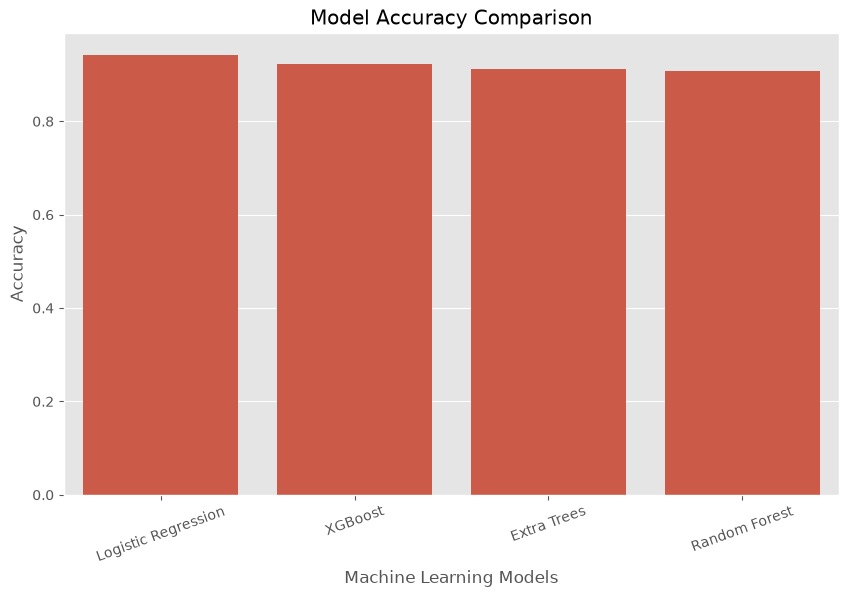

In [55]:
# ============================================
# Step 22: Model Accuracy Comparison
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x=results_df.index,
    y=results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

## Step 23: Classification Report

In [56]:
from sklearn.metrics import classification_report

best_model = models["Logistic Regression"]

predictions = best_model.predict(X_test_scaled)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94     27330
           1       0.94      0.95      0.95     32670

    accuracy                           0.94     60000
   macro avg       0.94      0.94      0.94     60000
weighted avg       0.94      0.94      0.94     60000



## Step 24: Confusion Matrix

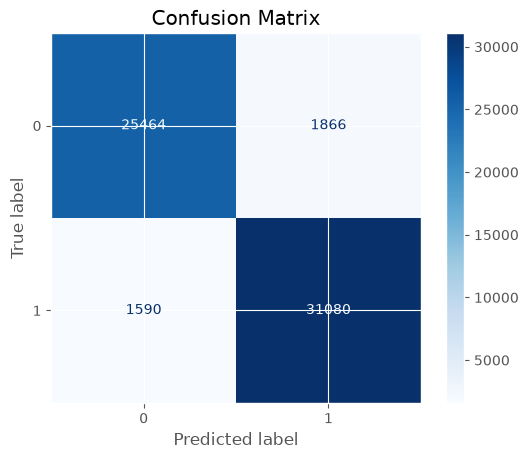

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

## Step 25: ROC Curve

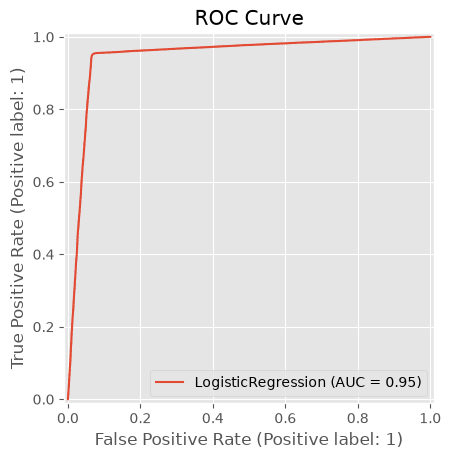

In [58]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")

plt.show()

## Step 26  : Feature Importance

In [59]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(15)

,Feature,Coefficient,Absolute
3,dsa_score,1.484238,1.484238
2,coding_skills,1.480410,1.480410
15,technical_skill_score,0.895115,0.895115
1,backlogs,-0.666428,0.666428
7,system_design,-0.587142,0.587142
6,ml_knowledge,-0.578724,0.578724
5,communication_skills,0.533624,0.533624
14,academic_performance,0.497193,0.497193
21,overall_student_performance,0.472184,0.472184
9,projects_count,-0.406088,0.406088


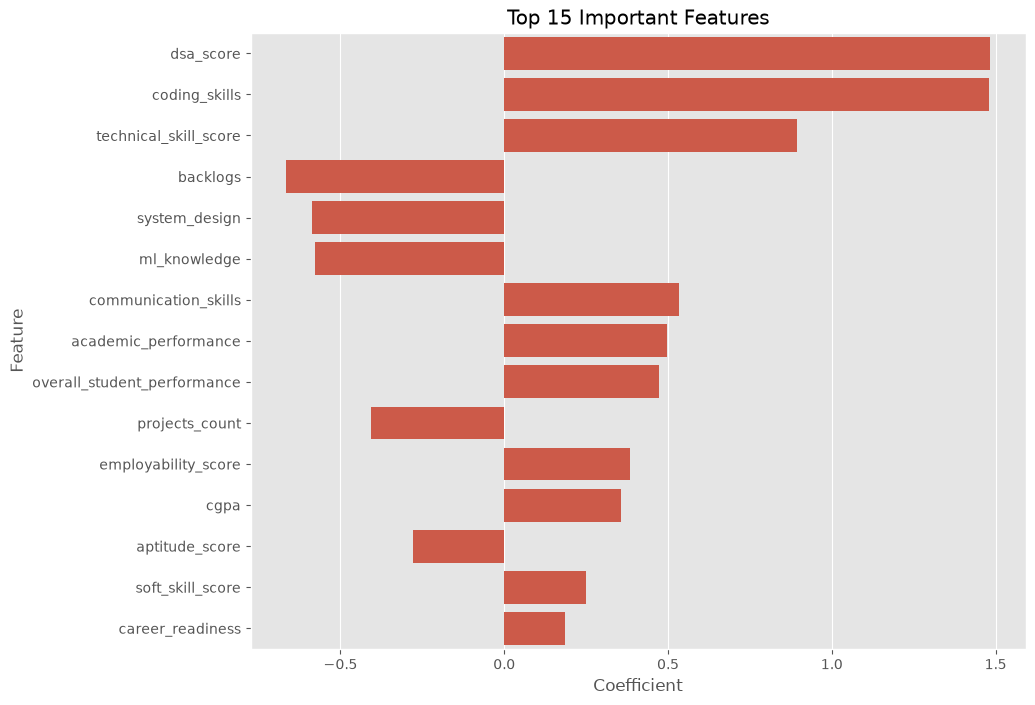

In [60]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

## Step 27: Hyperparameter Tuning of XGBoost using RandomizedSearchCV

In [61]:
# ============================================
# Step 27.1 Import Libraries
# ============================================

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [62]:
# ============================================
# Step 27.2 Base XGBoost Model
# ============================================

xgb_model = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

In [63]:
# ============================================
# Step 27.3 Hyperparameter Grid
# ============================================

param_grid = {

    "n_estimators":[
        100,
        200,
        300,
        500,
        700,
        1000
    ],

    "max_depth":[
        3,
        4,
        5,
        6,
        7,
        8,
        10
    ],

    "learning_rate":[
        0.005,
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "subsample":[
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree":[
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "gamma":[
        0,
        0.1,
        0.2,
        0.3,
        0.5,
        1
    ],

    "min_child_weight":[
        1,
        2,
        3,
        5,
        7
    ],

    "reg_alpha":[
        0,
        0.01,
        0.1,
        1
    ],

    "reg_lambda":[
        0.5,
        1,
        2,
        5
    ]
}

In [64]:
# ============================================
# Step 27.4 Randomized Search
# ============================================

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_grid,

    n_iter=50,

    scoring="accuracy",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.005, 0.01, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichre

In [65]:
# ============================================
# Step 27.5 Best Parameters
# ============================================

print("Best Parameters")

print(random_search.best_params_)

print()

print("Best Cross Validation Accuracy")

print(random_search.best_score_)

Best Parameters
{'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.9}

Best Cross Validation Accuracy
0.9300958333333333


In [66]:
# ============================================
# Step 27.6 Best Model
# ============================================

best_xgb = random_search.best_estimator_

best_xgb

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [67]:
# ============================================
# Step 27.7 Prediction
# ============================================

y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:,1]

In [68]:
# ============================================
# Step 27.8 Evaluation
# ============================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision :", precision_score(y_test,y_pred))

print("Recall :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print("ROC AUC :", roc_auc_score(y_test,y_prob))

Accuracy : 0.9302
Precision : 0.9308143756050339
Recall : 0.9418120599938782
F1 Score : 0.9362809238353164
ROC AUC : 0.9466155697054144


In [69]:
# ============================================
# Step 27.9 Classification Report
# ============================================

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92     27330
           1       0.93      0.94      0.94     32670

    accuracy                           0.93     60000
   macro avg       0.93      0.93      0.93     60000
weighted avg       0.93      0.93      0.93     60000



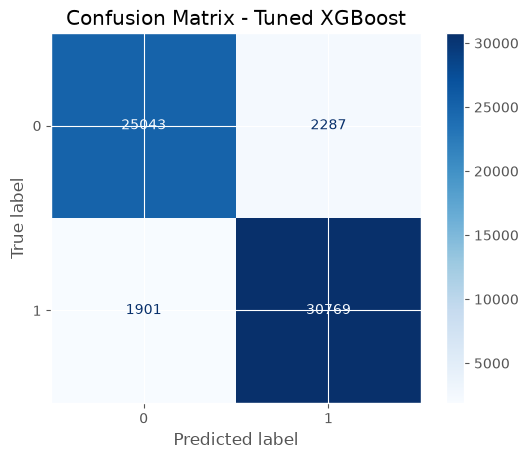

In [70]:
# ============================================
# Step 27.10 Confusion Matrix
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(

    best_xgb,

    X_test,

    y_test,

    cmap="Blues"

)

plt.title("Confusion Matrix - Tuned XGBoost")

plt.show()

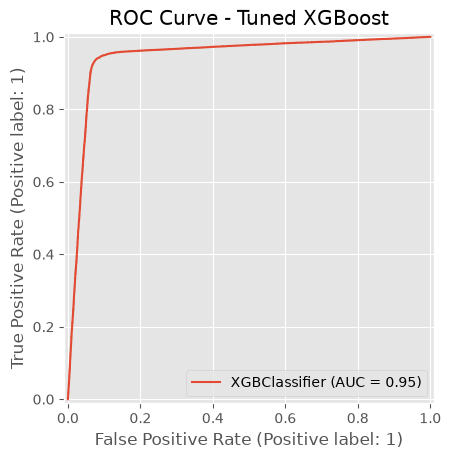

In [71]:
# ============================================
# Step 27.11 ROC Curve
# ============================================

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(

    best_xgb,

    X_test,

    y_test

)

plt.title("ROC Curve - Tuned XGBoost")

plt.show()

In [72]:
# ============================================
# Step 27.12 Feature Importance
# ============================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_xgb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
3,dsa_score,0.203431
2,coding_skills,0.198476
21,overall_student_performance,0.117925
14,academic_performance,0.113661
1,backlogs,0.092519
5,communication_skills,0.075253
8,internships,0.039999
9,projects_count,0.037252
15,technical_skill_score,0.025638
4,aptitude_score,0.008180


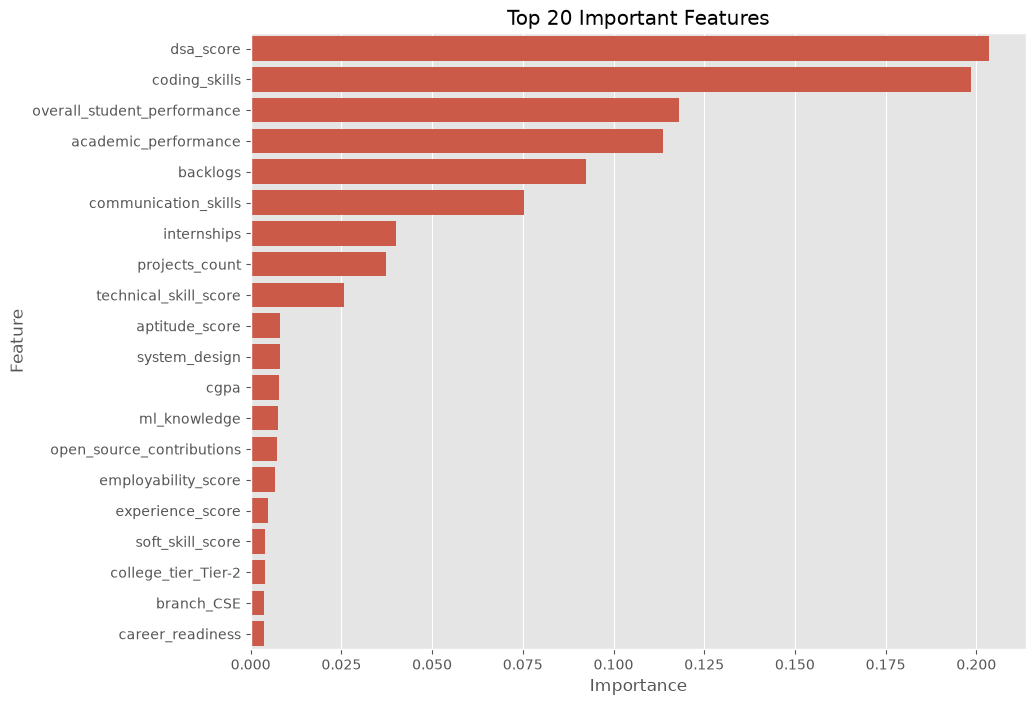

In [73]:
# ============================================
# Step 27.13 Importance Plot
# ============================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

## Step 28: Hyperparameter Tuning of Logistic Regression

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [75]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": [
        "liblinear",
        "lbfgs",
        "newton-cg",
        "saga"
    ],
    "penalty": ["l2"]
}

In [76]:
lr = LogisticRegression(
    random_state=42,
    max_iter=5000
)

In [77]:
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_searc

In [78]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}

Best CV Accuracy:
0.9420541666666666


In [79]:
best_lr = grid_search.best_estimator_

best_lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'newton-cg'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Ne

In [80]:
y_pred = best_lr.predict(X_test_scaled)

y_prob = best_lr.predict_proba(X_test_scaled)[:,1]

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.94245
Precision : 0.9434208529367127
Recall : 0.9513621059075604
F1 Score : 0.9473748380705631
ROC AUC : 0.9475830531417134


In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94     27330
           1       0.94      0.95      0.95     32670

    accuracy                           0.94     60000
   macro avg       0.94      0.94      0.94     60000
weighted avg       0.94      0.94      0.94     60000



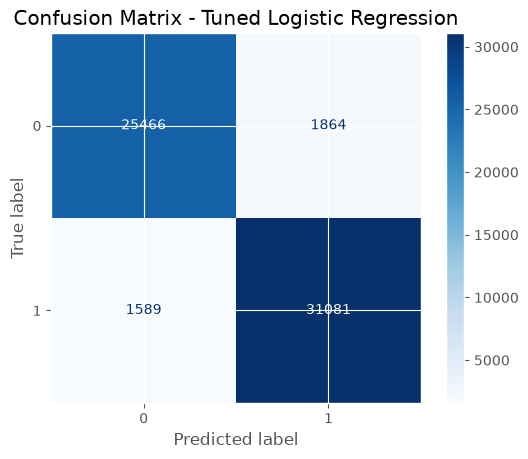

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Logistic Regression")

plt.show()

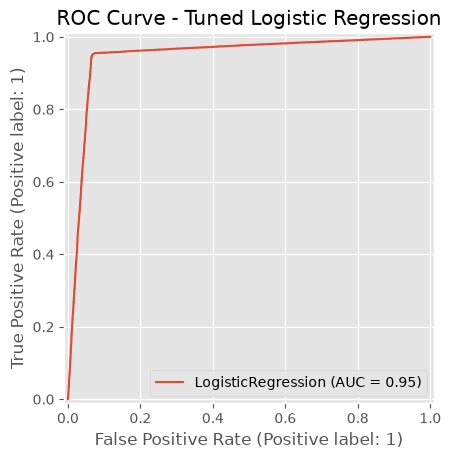

In [84]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_lr,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Tuned Logistic Regression")

plt.show()

In [85]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lr.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(20)

,Feature,Coefficient,Absolute
3,dsa_score,1.483546,1.483546
2,coding_skills,1.479781,1.479781
15,technical_skill_score,0.894987,0.894987
1,backlogs,-0.666066,0.666066
7,system_design,-0.586600,0.586600
6,ml_knowledge,-0.578206,0.578206
5,communication_skills,0.533442,0.533442
14,academic_performance,0.497109,0.497109
21,overall_student_performance,0.471925,0.471925
9,projects_count,-0.406074,0.406074


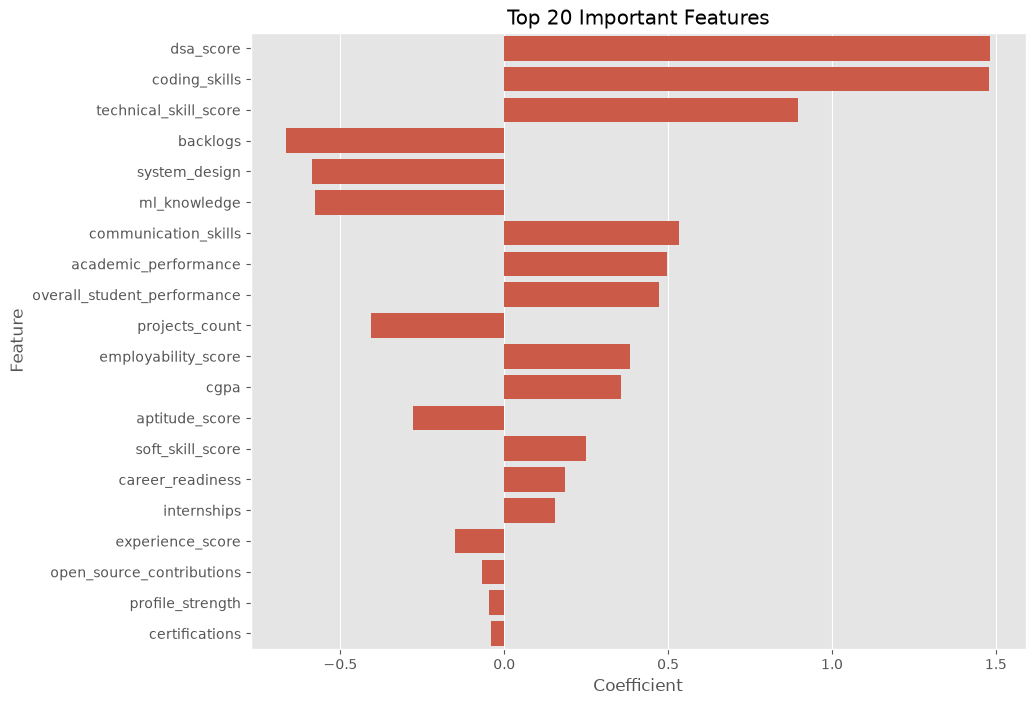

In [86]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

## Step 29: Save the Final Model

In [87]:
best_lr = grid_search.best_estimator_

In [88]:
import os
import joblib

# Create artifacts folder
os.makedirs("../artifacts", exist_ok=True)

# Save tuned Logistic Regression model
joblib.dump(best_lr, "../artifacts/model.pkl")

# Save scaler
joblib.dump(scaler, "../artifacts/scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [89]:
print(os.listdir("../artifacts"))

['.gitkeep', 'model.pkl', 'scaler.pkl']


# Step 30: Project Conclusion

In [90]:
print("=" * 70)
print("             Graduate Employability Prediction")
print("=" * 70)

print("\nProject Summary")
print("-" * 70)

print("Original Dataset Size      : 305,000 Records")
print("Dataset After Cleaning     : 300,000 Records")
print("Features Before Encoding   : 17")
print("Features After Encoding    : 30")

print("\nMachine Learning Models Evaluated")
print("-" * 70)

print("1. Logistic Regression")
print("2. Random Forest")
print("3. Extra Trees")
print("4. XGBoost")

print("\nModel Performance")
print("-" * 70)

print("Logistic Regression (Tuned) : 94.245%")
print("Random Forest              : 90.868%")
print("Extra Trees                : 91.177%")
print("XGBoost (Tuned)            : 93.020%")

print("\nFinal Selected Model")
print("-" * 70)

print("Tuned Logistic Regression")

print("\nReason")
print("-" * 70)

print("• Highest Accuracy")
print("• Highest Precision")
print("• Highest Recall")
print("• Excellent Cross Validation")
print("• Best Overall Performance")

print("\nProject Completed Successfully")

             Graduate Employability Prediction

Project Summary
----------------------------------------------------------------------
Original Dataset Size      : 305,000 Records
Dataset After Cleaning     : 300,000 Records
Features Before Encoding   : 17
Features After Encoding    : 30

Machine Learning Models Evaluated
----------------------------------------------------------------------
1. Logistic Regression
2. Random Forest
3. Extra Trees
4. XGBoost

Model Performance
----------------------------------------------------------------------
Logistic Regression (Tuned) : 94.245%
Random Forest              : 90.868%
Extra Trees                : 91.177%
XGBoost (Tuned)            : 93.020%

Final Selected Model
----------------------------------------------------------------------
Tuned Logistic Regression

Reason
----------------------------------------------------------------------
• Highest Accuracy
• Highest Precision
• Highest Recall
• Excellent Cross Validation
• Best Overall Pe

## Project Conclusion

This project developed a machine learning model to predict graduate employability using academic, technical, and extracurricular features.

A comprehensive data preprocessing pipeline was implemented, including missing value treatment, duplicate removal, feature engineering, categorical encoding, feature scaling, and train-test splitting.

Four supervised machine learning algorithms were evaluated:

- Logistic Regression
- Random Forest
- Extra Trees
- XGBoost

Hyperparameter tuning was performed on both XGBoost and Logistic Regression to improve predictive performance.

Among all evaluated models, the tuned Logistic Regression achieved the highest accuracy of **94.245%**, along with excellent Precision, Recall, F1-Score, and ROC-AUC values.

Therefore, the tuned Logistic Regression model was selected as the final deployment model for the Graduate Employability Prediction System.

This demonstrates that a carefully engineered feature set combined with a well-tuned linear classifier can outperform more complex ensemble methods for this dataset.

In [91]:
import sklearn
print(sklearn.__version__)

1.9.0


In [92]:
import pickle

with open("artifacts/model.pkl", "rb") as f:
    model = pickle.load(f)

print(type(model))
print(model)

FileNotFoundError: [Errno 2] No such file or directory: 'artifacts/model.pkl'

In [93]:
import os

print(os.getcwd())

d:\Machine_Learning_Assignment\Graduate_Employability_Prediction\notebooks


In [94]:
import pickle

model_path = r"D:\Machine_Learning_Assignment\Graduate_Employability_Prediction\artifacts\model.pkl"

with open(model_path, "rb") as f:
    model = pickle.load(f)

print(type(model))
print(model)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
LogisticRegression(C=0.1, max_iter=1000)
